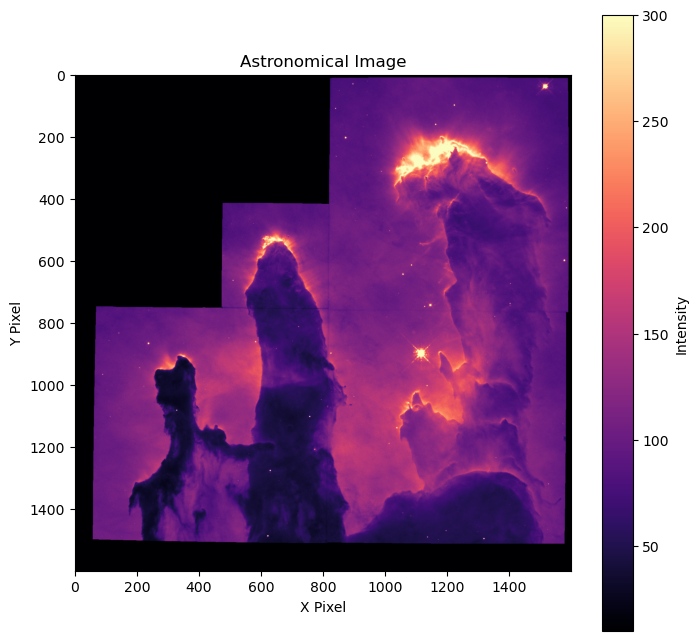

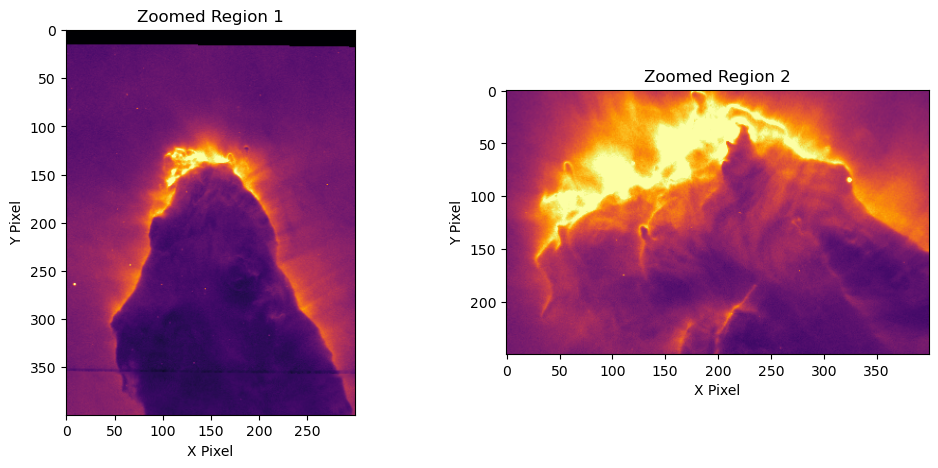

In [15]:
# Review

import numpy as np
import matplotlib.pyplot as plt

astro = np.loadtxt("astro_image.csv")

plt.figure(figsize=(8, 8))
plt.imshow(astro, cmap="magma", vmin = 10, vmax = 300)
plt.title("Astronomical Image")
plt.colorbar(label="Intensity")
plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")
plt.show()

zoom1 = astro[400:800, 500:800]
zoom2 = astro[200:450, 1000:1400]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(zoom1, cmap="inferno", vmin = 10, vmax = 300)
ax[0].set_title("Zoomed Region 1")
ax[0].set_xlabel("X Pixel")
ax[0].set_ylabel("Y Pixel")

ax[1].imshow(zoom2, cmap="inferno", vmin = 10, vmax = 300)
ax[1].set_title("Zoomed Region 2")
ax[1].set_xlabel("X Pixel")
ax[1].set_ylabel("Y Pixel")
plt.show()


In [17]:
import pandas as pd
df = pd.read_csv("ramen-ratings.csv")
df.columns

Index(['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten'], dtype='object')

In [21]:
df.loc[26, "Style"]

'Pack'

In [22]:
df["Brand"].nunique()

355

In [24]:
df_sorted = df.sort_values("Brand")
df_sorted.head()

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
229,2351,1 To 3 Noodles,Chatpat Masala,Pack,India,4,NaN
456,2124,7 Select,Nissin Instant Noodles Tom Yum Seafood Creamy ...,Bowl,Thailand,3.5,NaN
463,2117,7 Select,Nissin Instant Noodles Shrimp Ma Nao Lui Suan ...,Bowl,Thailand,4,NaN
877,1703,7 Select/Nissin,Super Tom Yum Shrimp,Cup,Thailand,3.5,NaN
911,1669,A-One,Mi Ly Instant Noodles Mi Chay Vegetarian Flavor,Cup,Vietnam,1.25,NaN


In [25]:
df[df["Country"] == "USA"]["Brand"].nunique()

49

In [26]:
usa_pack_brands = df[(df["Country"] == "USA") & (df["Style"] == "Pack")]["Brand"].nunique()
usa_pack_brands

27

In [27]:
top_ten_brands = df[df["Top Ten"].notna()]["Brand"].unique()
top_ten_brands

array(['MAMA', 'Prima Taste', 'Prima', 'Tseng Noodles', 'Wugudaochang',
       'A-Sha Dry Noodle', 'MyKuali', 'CarJEN', 'Maruchan', 'Mamee',
       'Mama', 'Sapporo Ichiban', 'Nongshim', 'Samyang Foods', 'Paldo',
       'Indomie', 'Koka', 'Mi Sedaap', 'Nissin', 'Myojo', 'Doll'],
      dtype=object)

In [33]:
from astropy.table import Table
import pandas as pd
from numpy.polynomial.polynomial import polyfit

table = Table.read("global_CCl4_MM.dat", format="ascii")
table

CCl4ottoyr,CCl4ottomon,CCl4ottoNHm,CCl4ottoNHsd,CCl4ottoSHm,CCl4ottoSHsd,CCl4ottoGLm,CCl4ottoGLsd
int64,int64,float64,float64,float64,float64,float64,float64
1996,1,nan,nan,nan,nan,nan,nan
1996,2,nan,nan,nan,nan,nan,nan
1996,3,nan,nan,nan,nan,nan,nan
1996,4,105.318,0.197,102.969,0.238,104.144,0.155
1996,5,105.032,0.193,102.754,0.287,103.893,0.174
1996,6,105.327,0.277,103.086,0.273,104.207,0.191
1996,7,105.25,0.171,103.021,0.233,104.136,0.147
1996,8,104.855,0.239,102.817,0.213,103.836,0.161
1996,9,104.909,0.248,102.813,0.441,103.861,0.254


In [35]:
df = table.to_pandas()
df = df[['CCl4ottoyr', 'CCl4ottomon', 'CCl4ottoGLm', 'CCl4ottoGLsd']]
df['date'] = df['CCl4ottoyr'] + (df['CCl4ottomon'] - 1) / 12
df.head()

,CCl4ottoyr,CCl4ottomon,CCl4ottoGLm,CCl4ottoGLsd,date
0,1996,1,NaN,NaN,1996.000000
1,1996,2,NaN,NaN,1996.083333
2,1996,3,NaN,NaN,1996.166667
3,1996,4,104.144,0.155,1996.250000
4,1996,5,103.893,0.174,1996.333333


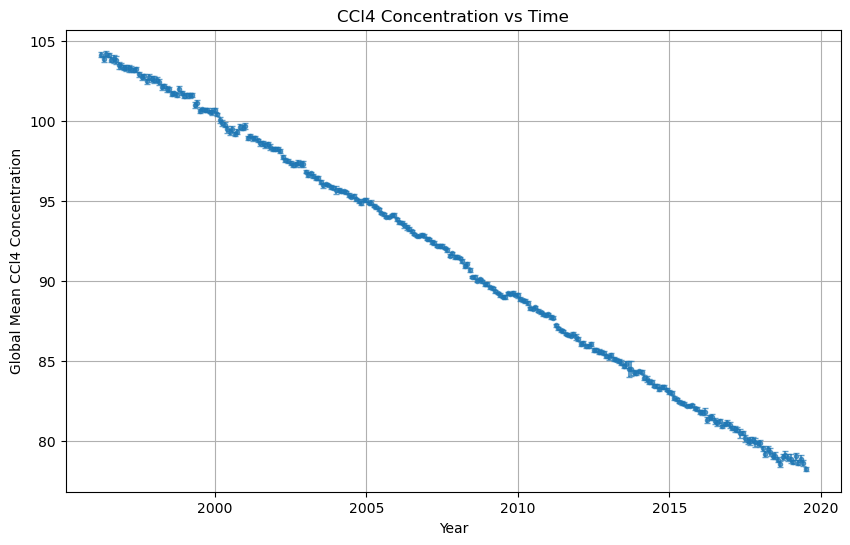

In [39]:
plt.figure(figsize=(10,6))

plt.errorbar(
    df['date'],
    df['CCl4ottoGLm'],
    yerr=df['CCl4ottoGLsd'],
    fmt='o',
    markersize=3,
    capsize=2,
    alpha=0.7
)

plt.xlabel("Year")
plt.ylabel("Global Mean CCl4 Concentration")
plt.title("CCl4 Concentration vs Time")
plt.grid(True)

plt.show()

In [41]:
mask = (~df['CCl4ottoGLm'].isna()) & (~df['CCl4ottoGLsd'].isna())
x_clean = df.loc[mask, 'date'].values
y_clean = df.loc[mask, 'CCl4ottoGLm'].values

m, b = np.polyfit(x_clean, y_clean, 1)
df['fit_linear'] = m * df['date'] + b

print(f"Linear fit: y = {m:.4f}x + {b:.4f}")

Linear fit: y = -1.1460x + 2392.4044


In [43]:
ydata = df.loc[mask, 'CCl4ottoGLm'].values
sigma = df.loc[mask, 'CCl4ottoGLsd'].values
yexp_linear = df.loc[mask, 'fit_linear'].values

chi2_linear = np.sum((yexp_linear - ydata)**2 / sigma**2)
red_chi2_linear = chi2_linear / (np.sum(mask) - 1)

print("Reduced chi-square (linear):", red_chi2_linear)

Reduced chi-square (linear): 4.590276168556381


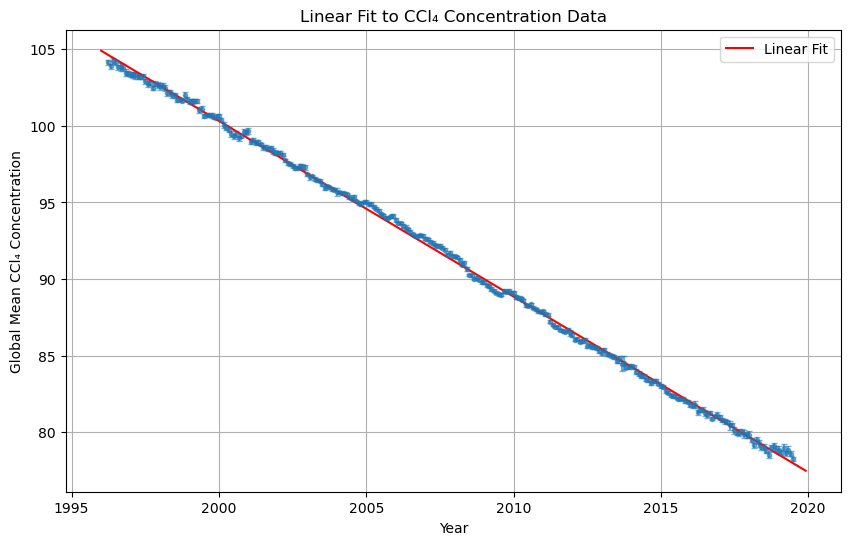

In [45]:
plt.figure(figsize=(10,6))
plt.errorbar(
    df['date'],
    df['CCl4ottoGLm'],
    yerr=df['CCl4ottoGLsd'],
    fmt='o',
    markersize=3,
    capsize=2,
    alpha=0.6
)
plt.plot(df['date'], df['fit_linear'], color='red', label="Linear Fit")
plt.xlabel("Year")
plt.ylabel("Global Mean CCl₄ Concentration")
plt.title("Linear Fit to CCl₄ Concentration Data")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
import random

class PlayingCharacter:
    def __init__(self, name, race, char_class, age):
        self.name = name            # Name of character
        self.race = race            # Race (e.g., Elf, Dwarf)
        self.char_class = char_class  # Class (e.g., Wizard, Fighter)
        self.age = age              # Age in years
        self.level = 1              # Initial level is always 1
        self.stats = {}             # Will hold character stats after rolling

    def roll_stats(self, order=None):
        # Roll 6 random stats from 1 to 20 (common RPG range)
        rolls = [random.randint(1, 20) for _ in range(6)]

        # Default stat keys
        keys = ["Strength", "Dexterity", "Constitution", "Intelligence", "Wisdom", "Charisma"]

        if order == "high_to_low":
            rolls.sort(reverse=True)

        self.stats = {k: v for k, v in zip(keys, rolls)}

    def level_up(self):
        # Increases level by 1
        self.level += 1
        print(f"{self.name} leveled up to level {self.level}!")

    def __repr__(self):
        return (f"<PlayingCharacter(name={self.name}, race={self.race}, class={self.char_class}, "
                f"age={self.age}, level={self.level}, stats={self.stats})>")


character = PlayingCharacter("Oski", "Elf", "Wizard", 120)

character.roll_stats(order="high_to_low")

print(character)  
character.level_up()

print(f"Stats: {character.stats}")
print(f"Level: {character.level}")
